# Exploración del Entorno CartPole-v1

Este notebook contiene la exploración inicial del entorno CartPole-v1 de Gymnasium, necesaria para comprender el espacio de observaciones y diseñar una estrategia de discretización adecuada para la implementación de Q-Learning.

## Importación de librerías

In [1]:
import gymnasium as gym
import numpy as np
import random

In [2]:
# Inicializar el entorno en modo sin visualización para análisis
env = gym.make('CartPole-v1', render_mode=None)

## Análisis del espacio de observaciones

El espacio de observaciones de CartPole-v1 es continuo y contiene 4 variables.

In [3]:
print("Espacio de observaciones:", env.observation_space)
print("Límites inferiores:", env.observation_space.low)
print("Límites superiores:", env.observation_space.high)

Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Límites inferiores: [-4.8               -inf -0.41887903        -inf]
Límites superiores: [4.8               inf 0.41887903        inf]


## Análisis del espacio de acciones

El espacio de acciones determina los movimientos que puede realizar el agente.

In [4]:
print("Espacio de acciones:", env.action_space)
print("Número de acciones:", env.action_space.n)
print("Acción 0: Empujar el carro hacia la izquierda")
print("Acción 1: Empujar el carro hacia la derecha")

Espacio de acciones: Discrete(2)
Número de acciones: 2
Acción 0: Empujar el carro hacia la izquierda
Acción 1: Empujar el carro hacia la derecha


## Exploración de rangos reales de las variables

Dado que los límites teóricos del espacio de observaciones incluyen infinitos, es necesario ejecutar episodios aleatorios para determinar los rangos reales que toman las variables durante el juego. Esta información será fundamental para diseñar una discretización efectiva.

In [5]:
# Ejecutar episodios aleatorios para observar los rangos reales
num_episodes = 100
observations = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    done = False
    
    while not done:
        observations.append(obs)
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

observations = np.array(observations)

# Calcular estadísticas de cada variable
variables = ['Posición del carro', 'Velocidad del carro', 'Ángulo del poste', 'Velocidad angular del poste']
print("Estadísticas de las variables observadas en {} episodios aleatorios:\n".format(num_episodes))

for i, var_name in enumerate(variables):
    print(f"{var_name}:")
    print(f"  Mínimo: {observations[:, i].min():.4f}")
    print(f"  Máximo: {observations[:, i].max():.4f}")
    print(f"  Media: {observations[:, i].mean():.4f}")
    print(f"  Desviación estándar: {observations[:, i].std():.4f}")
    print()

Estadísticas de las variables observadas en 100 episodios aleatorios:

Posición del carro:
  Mínimo: -0.2198
  Máximo: 0.4368
  Media: 0.0025
  Desviación estándar: 0.0730

Velocidad del carro:
  Mínimo: -1.7900
  Máximo: 1.9322
  Media: 0.0279
  Desviación estándar: 0.5365

Ángulo del poste:
  Mínimo: -0.2094
  Máximo: 0.2090
  Media: -0.0004
  Desviación estándar: 0.0936

Velocidad angular del poste:
  Mínimo: -2.5224
  Máximo: 2.5230
  Media: -0.0235
  Desviación estándar: 0.8065



## Análisis de criticidad de las variables

Según la documentación de CartPole-v1, el episodio termina cuando:
- La posición del carro excede ±2.4 unidades
- El ángulo del poste excede ±12 grados (≈ ±0.2095 radianes)

Las variables relacionadas con el ángulo del poste son críticas para mantener el equilibrio, mientras que la posición del carro tiene un margen más amplio.

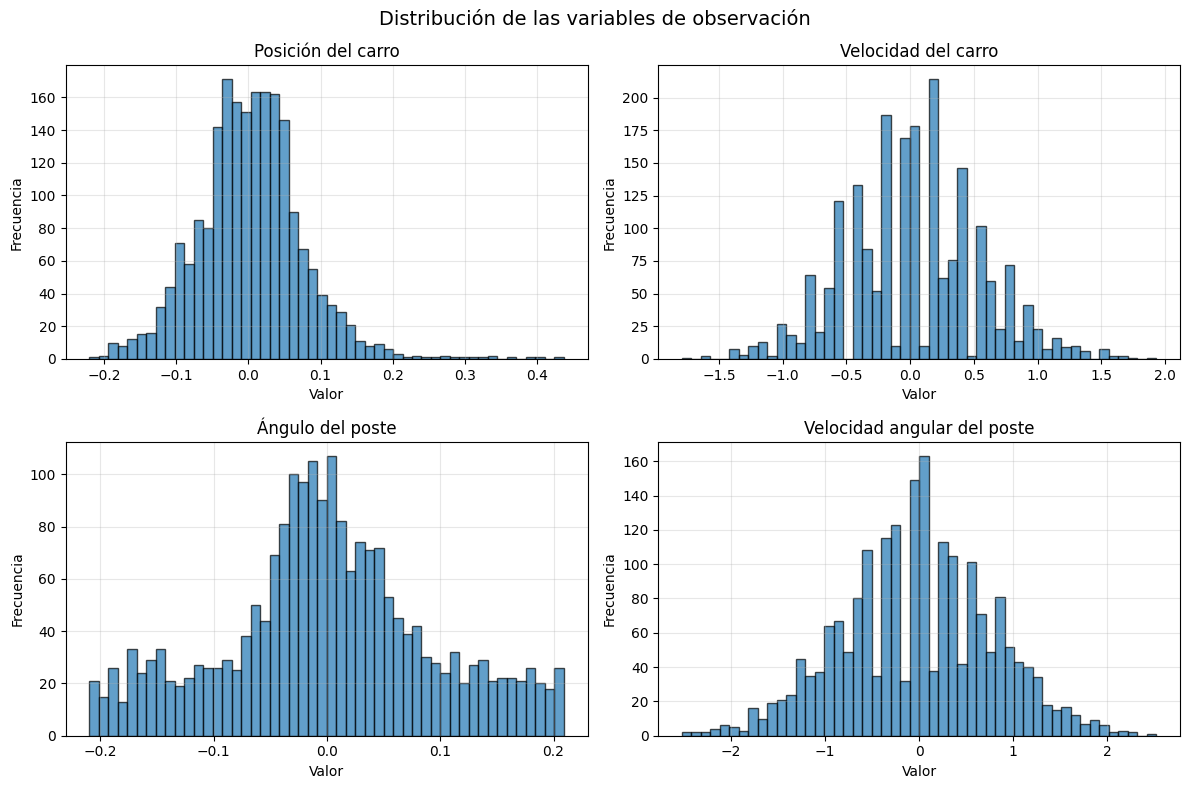

In [6]:
# Visualizar distribución de las variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de las variables de observación', fontsize=14)

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    ax.hist(observations[:, i], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Determinar rangos prácticos para discretización
# Usaremos percentiles para evitar valores extremos que rara vez ocurren

print("Rangos recomendados para discretización (basados en percentiles 1-99):\n")

for i, var_name in enumerate(variables):
    p1 = np.percentile(observations[:, i], 1)
    p99 = np.percentile(observations[:, i], 99)
    print(f"{var_name}:")
    print(f"  Rango sugerido: [{p1:.4f}, {p99:.4f}]")
    print()

Rangos recomendados para discretización (basados en percentiles 1-99):

Posición del carro:
  Rango sugerido: [-0.1676, 0.1986]

Velocidad del carro:
  Rango sugerido: [-1.2039, 1.3299]

Ángulo del poste:
  Rango sugerido: [-0.2006, 0.2025]

Velocidad angular del poste:
  Rango sugerido: [-1.9056, 1.8781]



## Conclusiones de la exploración

Los resultados de esta exploración nos permiten establecer:

1. **Variables críticas**: Ángulo del poste y velocidad angular del poste requieren mayor resolución en la discretización debido a su impacto directo en el equilibrio.

2. **Variables no críticas**: Posición y velocidad del carro pueden discretizarse con menos bins sin perder información esencial.

3. **Estrategia de discretización**: Se implementarán dos versiones:
   - Discretización gruesa: 3 bins para variables no críticas, 6 bins para variables críticas
   - Discretización fina: 6 bins para variables no críticas, 12 bins para variables críticas

## Definición de rangos óptimos para discretización

Basándonos en el análisis realizado, los límites de terminación del entorno y las mejores prácticas, se establecen los siguientes rangos para la discretización:

In [ ]:
# Definición de rangos para discretización
# Estos rangos serán utilizados en las implementaciones de Q-Learning

# Variables NO CRÍTICAS (menor impacto en terminación del episodio)
cart_position_range = (-2.4, 2.4)        # Límite exacto de terminación del entorno
cart_velocity_range = (-3.0, 3.0)        # Rango amplio que cubre comportamiento de políticas entrenadas

# Variables CRÍTICAS (impacto directo en equilibrio del poste)
pole_angle_range = (-0.21, 0.21)         # Límite exacto de terminación (±12 grados)
pole_angular_velocity_range = (-3.5, 3.5)  # Rango que captura estados de alta velocidad angular

print("Rangos definidos para discretización:\n")
print(f"Posición del carro: {cart_position_range}")
print(f"Velocidad del carro: {cart_velocity_range}")
print(f"Ángulo del poste: {pole_angle_range}")
print(f"Velocidad angular del poste: {pole_angular_velocity_range}")

### Justificación de los rangos seleccionados

**Posición del carro** `[-2.4, 2.4]`:
- Corresponde al límite exacto de terminación del entorno
- Aunque en episodios aleatorios no se exploró completamente, un agente entrenado necesitará acceder a todo el rango

**Velocidad del carro** `[-3.0, 3.0]`:
- Rango observado en episodios aleatorios: aproximadamente ±1.9
- Se amplía para capturar velocidades mayores que puede desarrollar un agente entrenado
- Valor conservador que equilibra cobertura y eficiencia de la tabla Q

**Ángulo del poste** `[-0.21, 0.21]` rad (±12°):
- Variable más crítica: el episodio termina si se excede este límite
- Usar el límite exacto asegura que todos los estados válidos estén representados
- Requiere mayor resolución en la discretización

**Velocidad angular del poste** `[-3.5, 3.5]` rad/s:
- Segunda variable crítica: determina si el poste se recupera o continúa cayendo
- Rango observado: aproximadamente ±2.5
- Se amplía para capturar situaciones límite donde el agente debe realizar correcciones agresivas
- Requiere mayor resolución en la discretización